In [1]:
import glob

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import cartopy.crs as ccrs
import cartopy
import xarray as xr
import xclim as xc
import numpy as np
import cmocean
import geopandas as gp

from unseen import fileio
from unseen import spatial_selection as ss

## Shapefile

In [2]:
lgas_file = '/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/aus_local_gov/aus_local_gov.shp'
lgas = gp.read_file(lgas_file)

In [3]:
nsw_lgas = lgas[lgas['STE_NAME21'] == 'New South Wales']

In [4]:
newcastle_lgas = ['Newcastle', 'Port Stephens', 'Maitland', 'Cessnock', 'Lake Macquarie']
greater_newcastle = nsw_lgas[nsw_lgas['LGA_NAME22'].isin(newcastle_lgas)]

In [5]:
greater_newcastle = greater_newcastle.dissolve()
greater_newcastle['LGA_NAME22'][0] = 'Greater Newcastle'

/jobfs/150052814.gadi-pbs/ipykernel_829525/1609558905.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  greater_newcastle['LGA_NAME22'][0] = 'Greater Newcastle'
/jobfs/150052814.gadi-pbs/ipykernel_829525/1609558905.py:2: SettingWithCopyWar

In [6]:
pasha_lga_list = newcastle_lgas + ['Central Coast (NSW)',]
pasha_lgas = nsw_lgas[nsw_lgas['LGA_NAME22'].isin(pasha_lga_list)]

In [7]:
pasha_area = pasha_lgas.dissolve()
pasha_area['LGA_NAME22'][0] = 'Pasha Bulker LGAs'

/jobfs/150052814.gadi-pbs/ipykernel_829525/1945754997.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pasha_area['LGA_NAME22'][0] = 'Pasha Bulker LGAs'
/jobfs/150052814.gadi-pbs/ipykernel_829525/1945754997.py:2: SettingWithCopyWarning: 


## Hour-by-hour rainfall

In [32]:
barra_file = '/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/pr/latest/pr_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_200706-200706.nc'

In [37]:
ds = fileio.open_dataset(barra_file, units={'pr': 'mm/hr'})

In [38]:
ds = ds.sel(time=slice('2007-06-08', '2007-06-09'))

In [39]:
ds = ds.compute()

In [40]:
ds

<xarray.Dataset> Size: 507MB
Dimensions:    (time: 48, lat: 1018, lon: 1298, bnds: 2)
Coordinates:
  * time       (time) object 384B 2007-06-08 00:30:00 ... 2007-06-09 23:30:00
  * lat        (lat) float64 8kB -45.69 -45.65 -45.61 ... -5.09 -5.05 -5.01
  * lon        (lon) float64 10kB 108.0 108.1 108.1 108.1 ... 159.8 159.9 159.9
    crs        int32 4B 0
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float64 507MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    time_bnds  (time, bnds) object 768B 2007-06-08 00:00:00 ... 2007-06-10 00...
Attributes: (12/60)
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    axiom_schema:              cordex-1H.json
    productive_version:        8935ea8
    variable_version:          v20240516
    Conventions:               CF-1.10, ACDD-1.3
    ...                        ...
    date_modified:             2024-10-11T00:33:30Z
    date_metadata_modified:    2024-10-11T00:33:30Z
    history:                   Tue Apr 23 04:59:29 2024: /g/data/access/ngm/m...
    references:                https://doi.org/10.25914/1x6g-2v48
    license:                   https://doi.org/10.25914/1x6g-2v48
    acknowledgement:           The production of BARRA2 was supported with fu...

/jobfs/150052814.gadi-pbs/ipykernel_829525/1525560515.py:10: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in p.axes.flat:


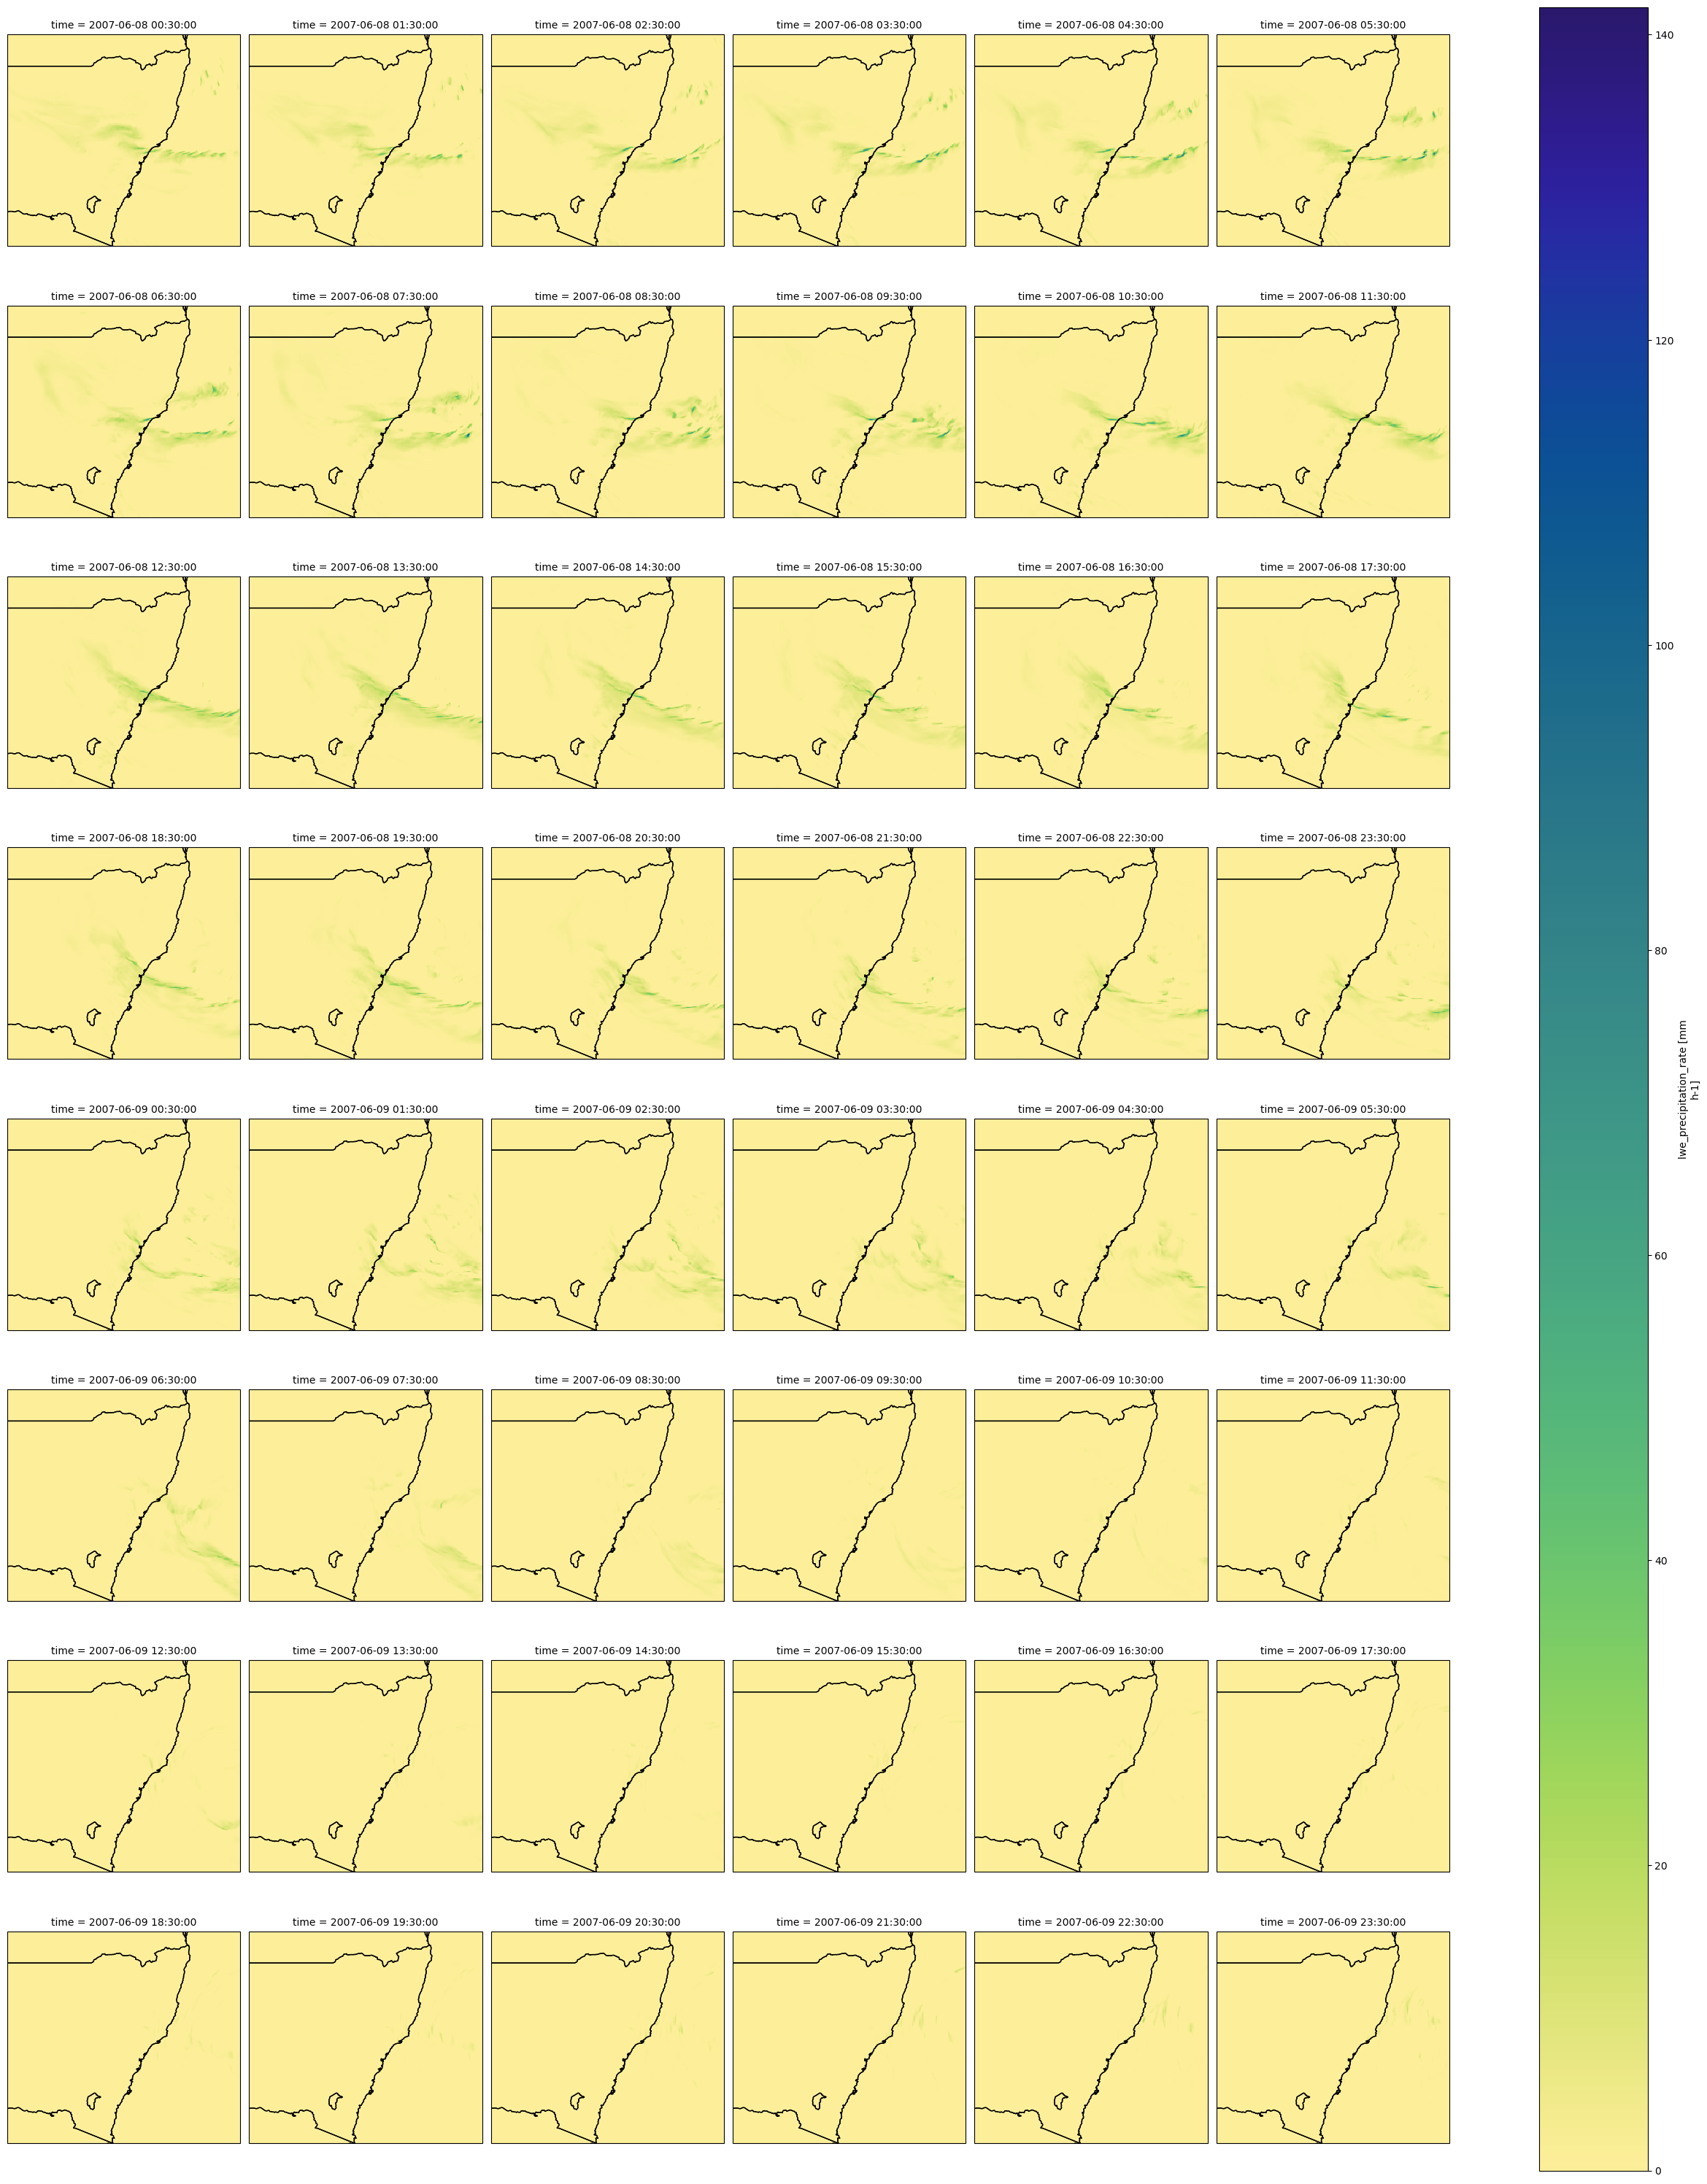

In [41]:
p = ds['pr'].plot(
    col='time',
    col_wrap=6,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.haline_r,
    figsize=[25, 30],
    subplot_kws={"projection": ccrs.PlateCarree()},
)

for ax in p.axes.flat:
    ax.coastlines()
    ax.add_feature(cartopy.feature.STATES)
    ax.set_extent([145, 156, -27.5, -37.5], crs=ccrs.PlateCarree())

#plt.savefig(
#    'jasper_day-by-day.png',
#    bbox_inches='tight',
#    facecolor='white',
#    dpi=100
#)
plt.show()

## Event summary

In [16]:
aus = gp.read_file('/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp')

In [17]:
aus_buffer = ss.shapefile_with_buffer(aus, 0.1)

In [33]:
#ds_masked['precip'].sel(time='2007-06-08')
#precip_total_masked_8Jun = precip_total_masked_8Jun.squeeze('time')

In [23]:
def plot_cities(ax, label_color='white'):
    lats = [-32.9, -33.9,]
    lons = [151.8, 151.2,]
    cities = ['Newcastle', 'Sydney']
    for lon, lat, city in zip(lons, lats, cities):
        ax.plot(lon, lat, 'ro', markersize=6, zorder=5, transform=ccrs.PlateCarree())
        ax.text(
            lon + 0.12,
            lat - 0.04,
            city,
            fontsize='large',
            color=label_color,
            transform=ccrs.PlateCarree()
        )

#cmap = plt.cm.Purples_r
#colors = [cmap(i) for i in np.linspace(0, 1, 10)] 
def plot_dots(ax, label_color='white'):
    lats = [-33.29, -32.9, -33.31, -32.95, -33.36, -33, -33.25, -33.25, -33.28, -32.89]
    lons = [151.21, 151.48, 151.24, 151.74, 151.33, 151.58, 151.32, 151.39, 151.58, 151.71]
    rank = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    for lon, lat, rank in zip(lons, lats, rank):
        ax.plot(lon, lat, color='red', marker='o', markersize=3, zorder=5, transform=ccrs.PlateCarree())
#        ax.text(
#            lon + 0.04,
#            lat - 0.04,
#            rank,
#            fontsize='large',
#            color=label_color,
#            transform=ccrs.PlateCarree()
#        )

In [24]:
def plot_map(da, pr_levels, title, zoom_in=False, cities=True, dots=False, outfile=None):
    """Plot the map"""
    
    fig = plt.figure(figsize=[12, 7])
    ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
    lw = 0.5
    cmap = cmocean.cm.rain
    # cmocean.cm.haline_r
    
    da.plot.contourf(
        ax=ax1,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        levels=pr_levels,
        cbar_kwargs={'label': 'mm'},
    )
    
    # Local government areas
    ax1.add_geometries(
        nsw_lgas.geometry,
        ccrs.PlateCarree(),
        facecolor='none',
        linewidth=lw,
        edgecolor='0.8',
    )
    ax1.add_geometries(
        pasha_area.geometry,
        ccrs.PlateCarree(),
        facecolor='none',
        linewidth=lw,
        edgecolor='tab:orange',
    )
    ax1.coastlines()
    ax1.add_feature(cartopy.feature.STATES)
    gl = ax1.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    ax1.plot(
        [151, 151, 152, 152, 151],
        [-32.5, -33.5, -33.5, -32.5, -32.5],
        transform=ccrs.PlateCarree(),
        color='black',
        linestyle=':'
    )
    if zoom_in:
        ax1.set_extent([150.75, 152.25, -32.25, -33.75], crs=ccrs.PlateCarree())
    else:
        ax1.set_extent([149, 152.5, -31.25, -34.25], crs=ccrs.PlateCarree())
    if cities:
        plot_cities(ax1, label_color='black')
    if dots:
        plot_dots(ax1)
    ax1.set_title(title)

    if outfile:
        plt.savefig(
            outfile,
            bbox_inches='tight',
            facecolor='white',
            dpi=300
        )
    plt.show()

In [84]:
ds_precip_total_9Jun = ds.isel(time=slice(9, 33)).sum(dim=['time'], min_count=1)

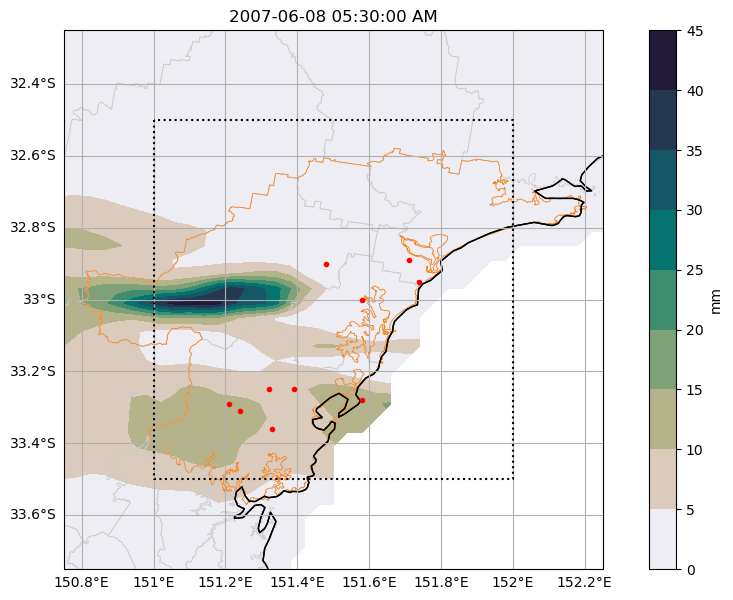

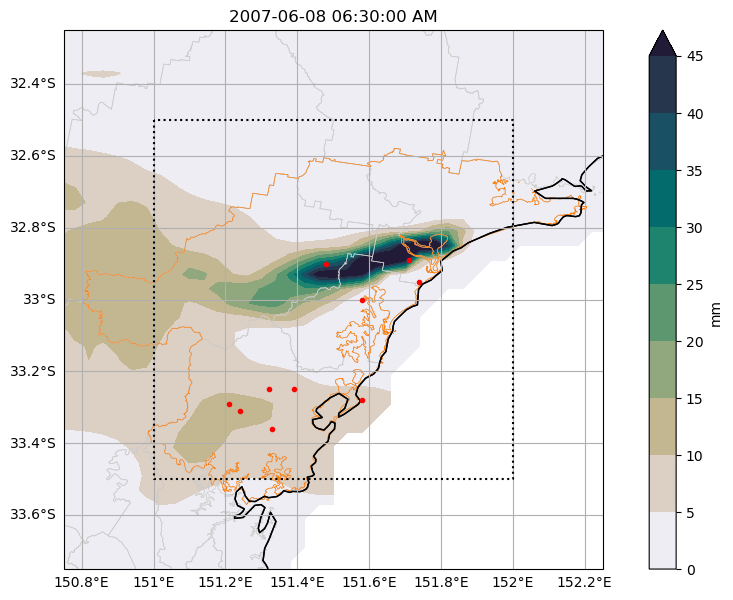

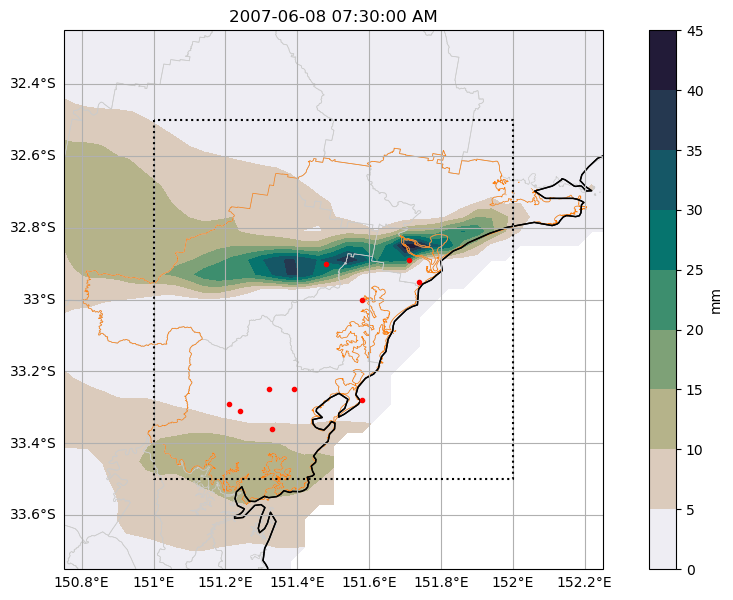

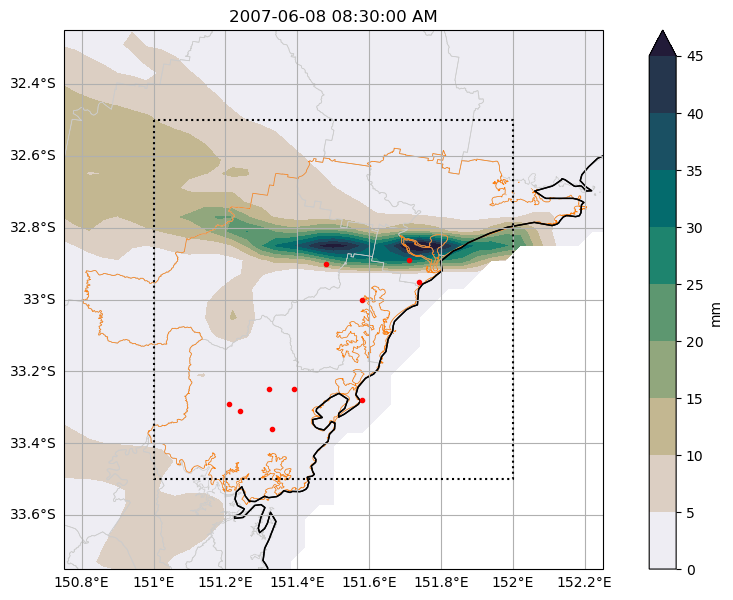

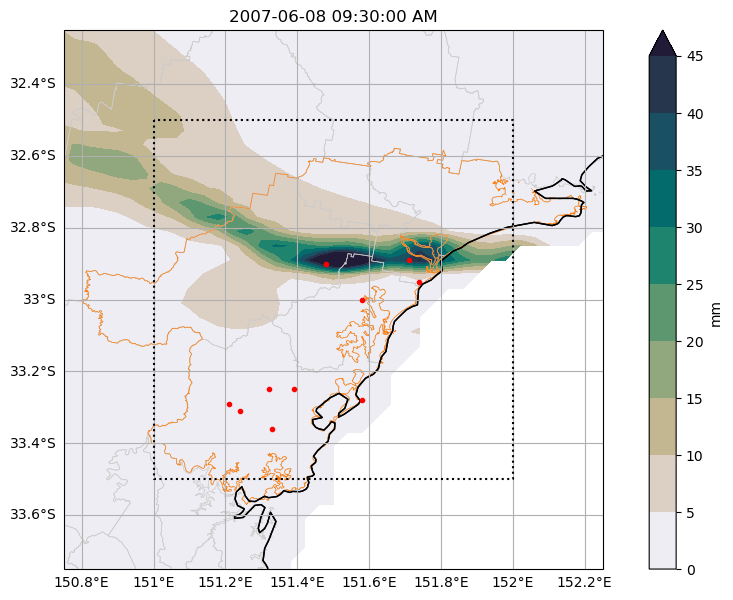

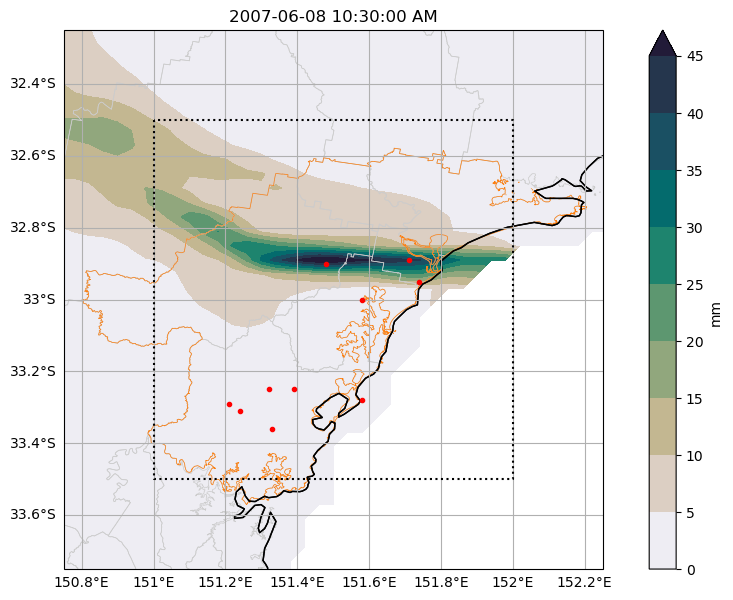

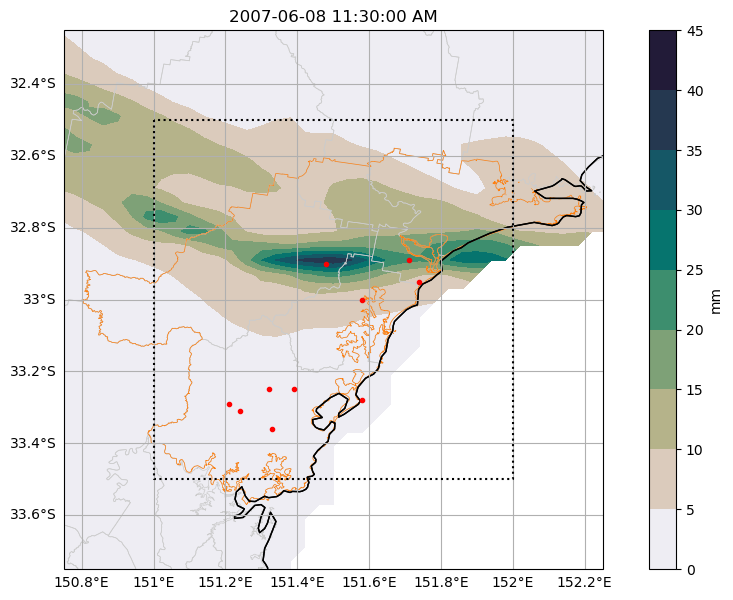

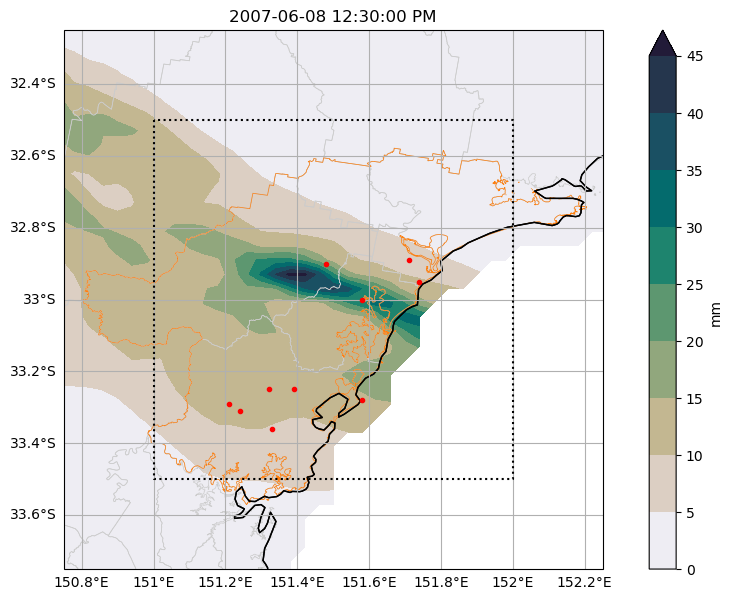

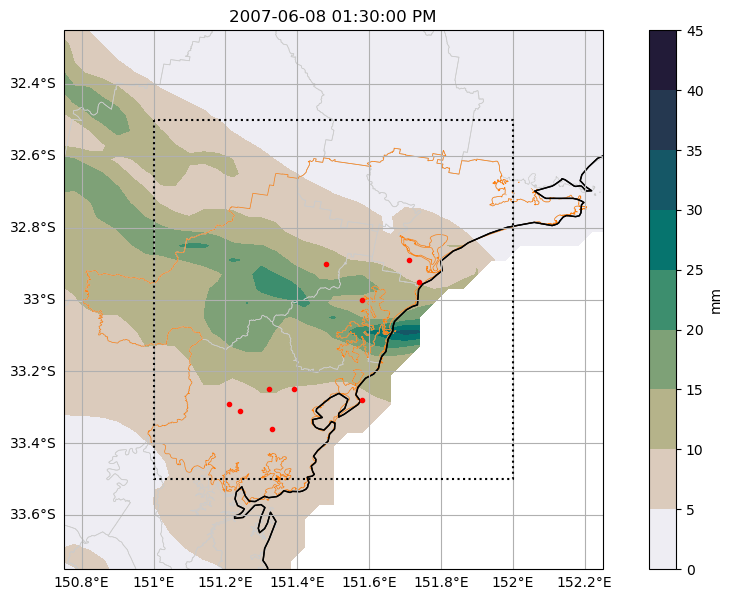

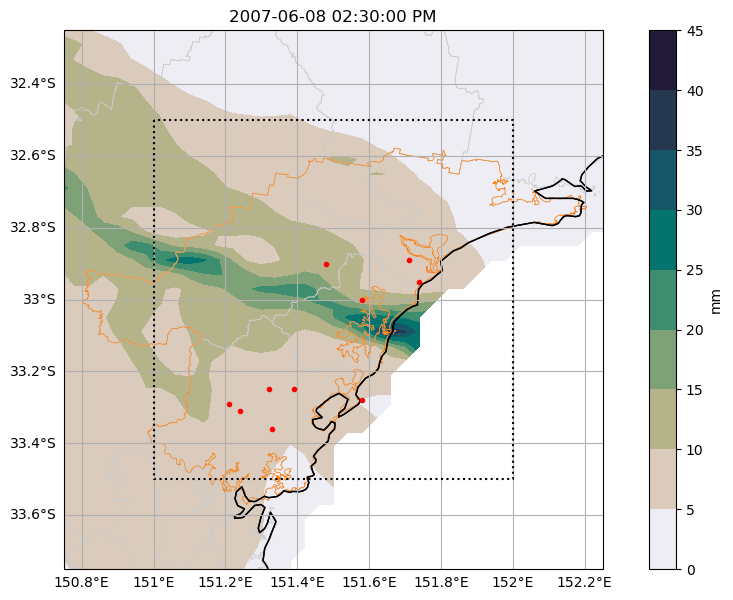

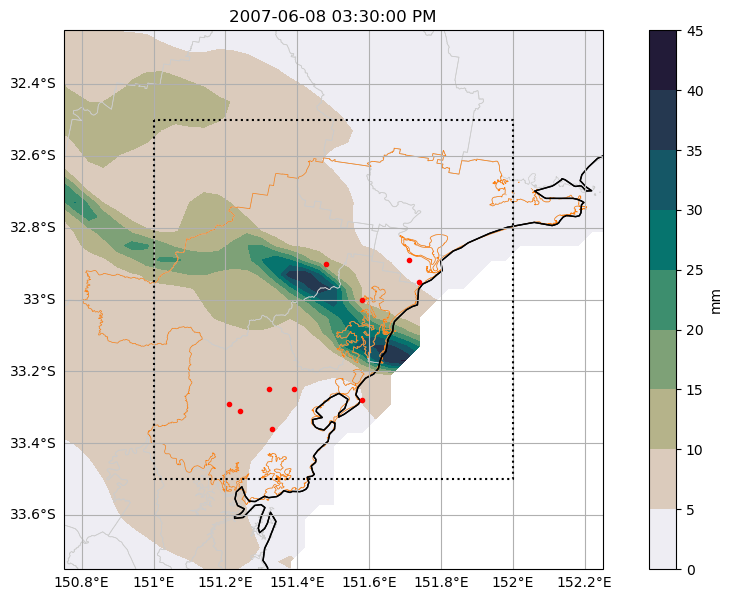

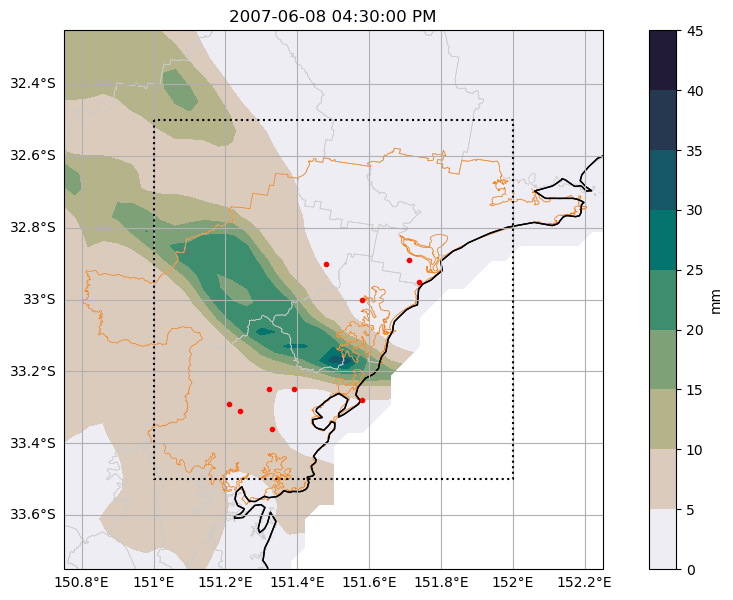

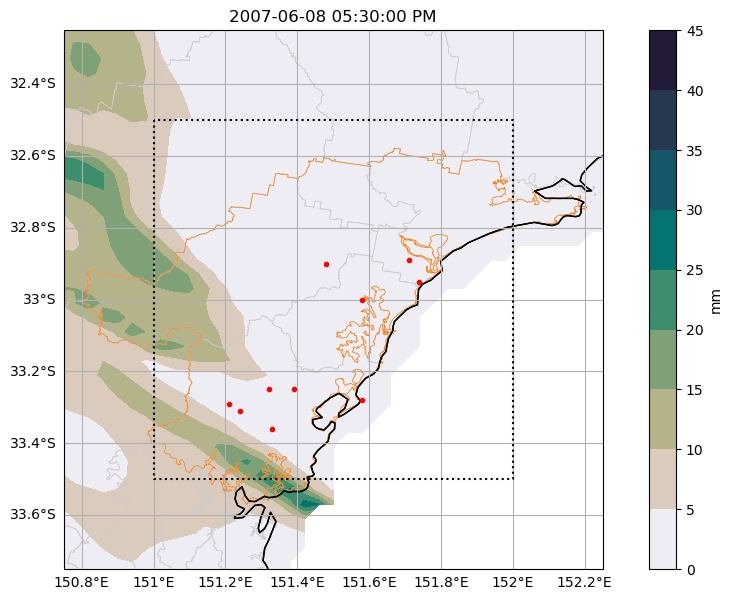

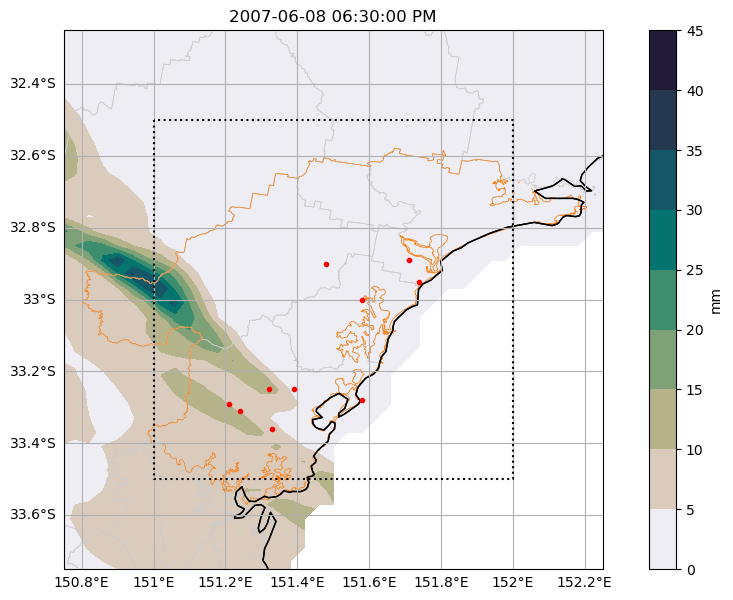

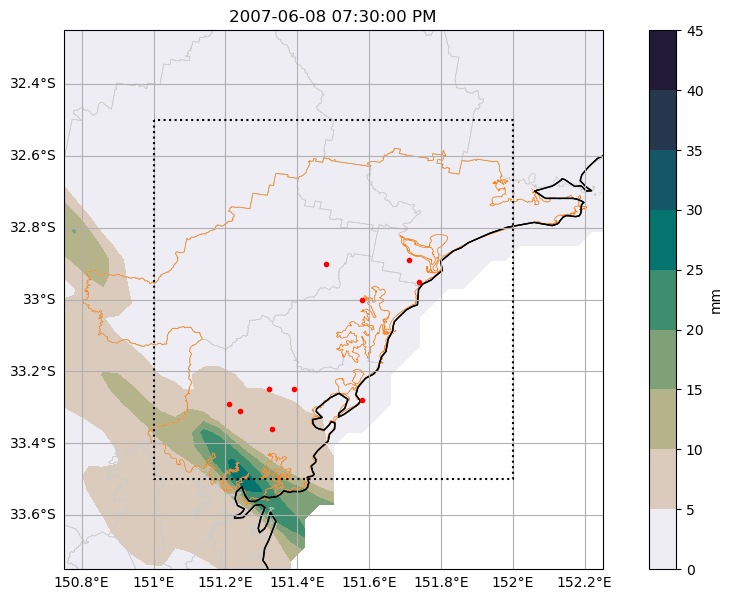

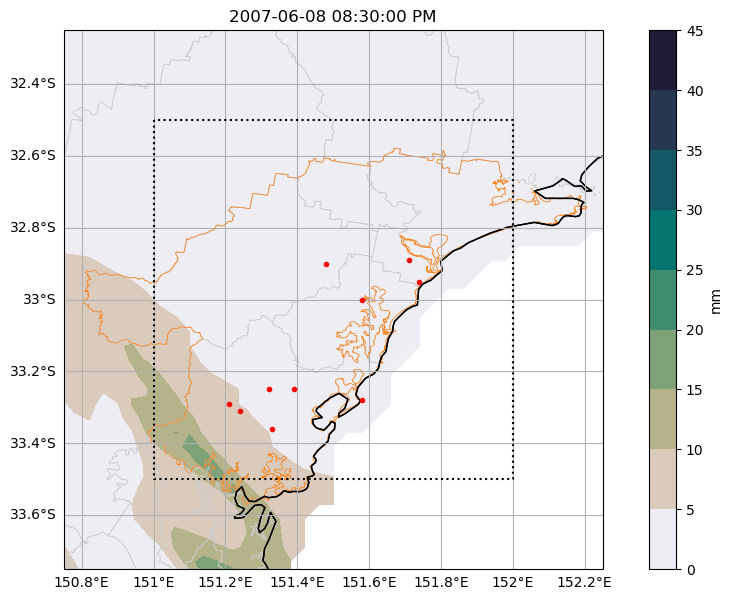

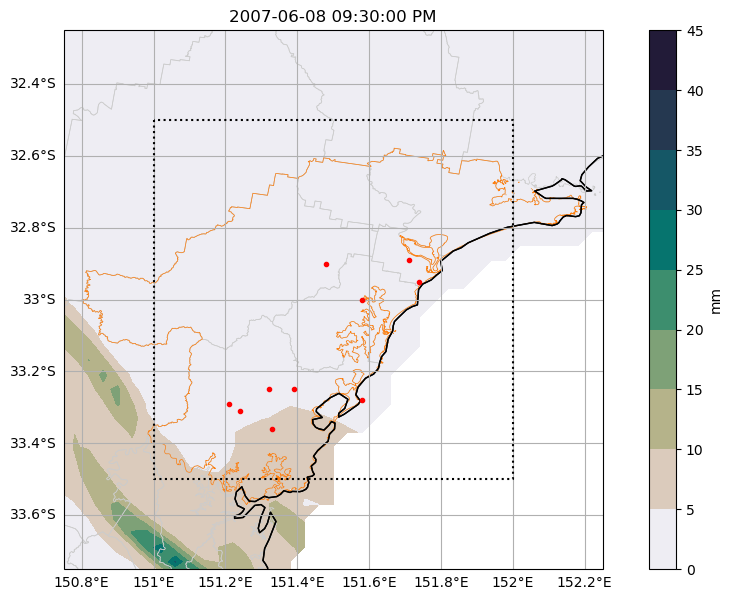

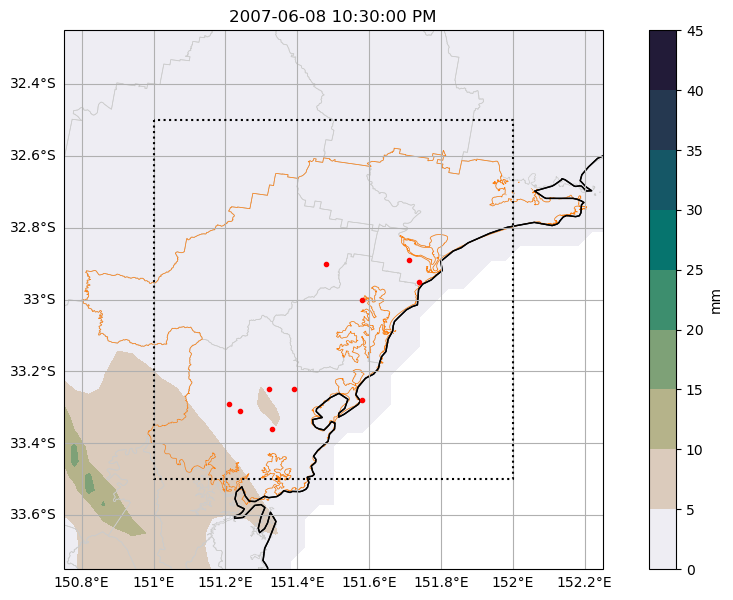

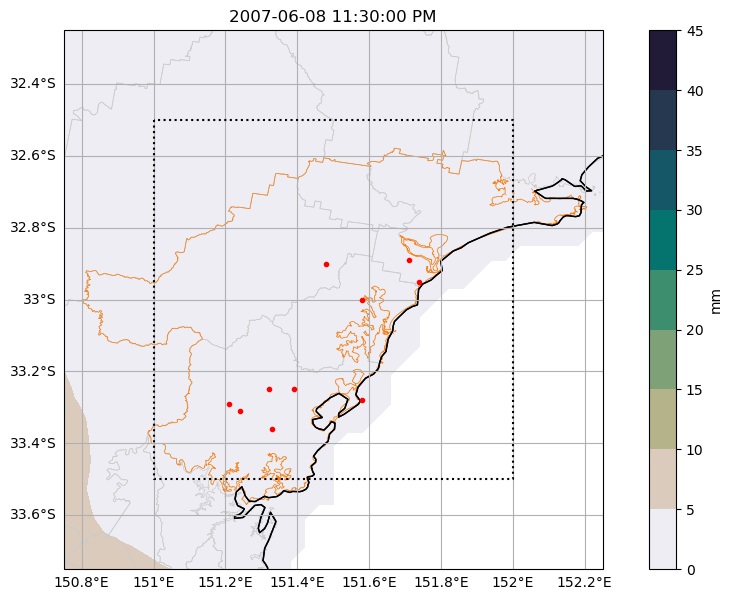

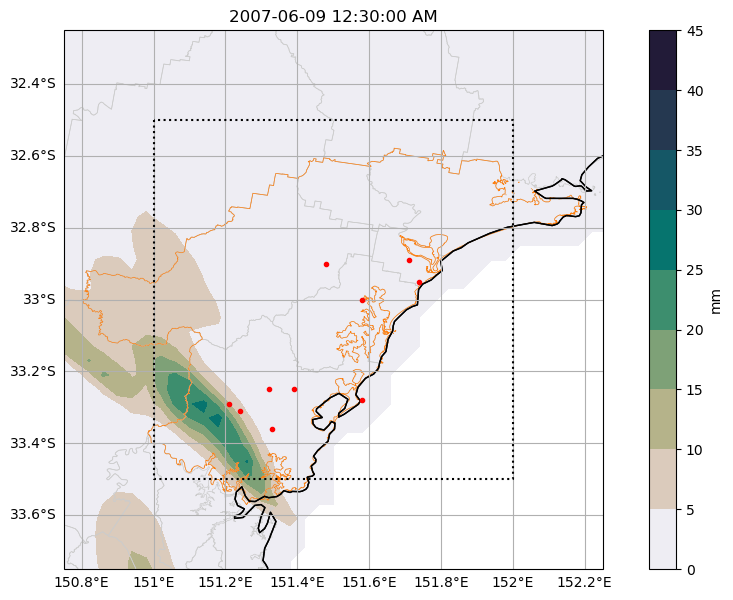

In [78]:
for tstep in [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]:
    ds_plot = ds.isel(time=tstep)
    ds_plot = ss.select_shapefile_regions(ds_plot, aus_buffer)
    plot_map(
        ds_plot['pr'],
        np.arange(0, 50, 5),
        str(ds_plot.time.dt.strftime('%Y-%m-%d %r').values),
        zoom_in=True,
        cities=False,
        dots=True
    )

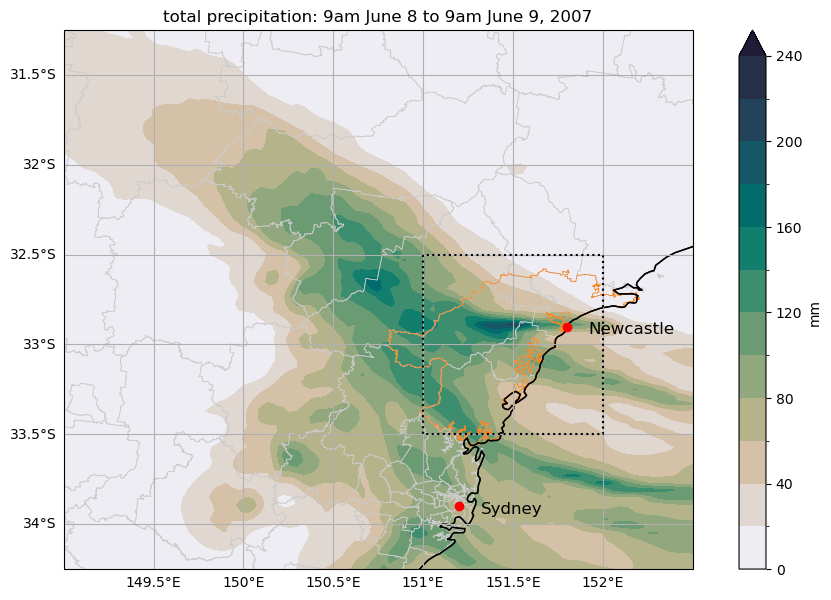

In [89]:
plot_map(
    ds_precip_total_9Jun['pr'],
    np.arange(0, 241, 20),
    'total precipitation: 9am June 8 to 9am June 9, 2007',
    dots=False,
    cities=True,
    zoom_in=False,
    outfile='map_9June_barra.png',
)